In [1]:
%pylab inline
from pycbc.events import hm_utils
from pycbc import detector

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


In [12]:
def check_time_delay_is_physical(
    n2, n3, N2, N3, alpha_23, rounding=True):
    """Check if the delay time between two detector combinations
    is geometrically possible. The units for time are arbritrary 
    but must be consistent. However if using rounding units must be 
    time indices. 
    
    Parameters
    ----------
    n2: float or array
        Delay time between ifo1 and ifo2.
    n3: float or array
        Delay time between ifo1 and ifo2.
    N2: float
        Light travel time between ifo1 and ifo2.
    N3: float
        Light travel time between ifo1 and ifo3.
    alpha_23: float
        Angle (in radians) between ifo2 and ifo3 viewed from ifo1.
    rounding: bool
        If True will include the point just outside the geometrical 
        region in the physical region.
        
    Returns
    -------
    cond: bool, or boolean array
        False if delay times are unphysical.
    """
    N3 = float(N3)
    p = N3 / N2 * np.cos(alpha_23)
    q = N3 / N2 * np.sin(alpha_23)
    if rounding:
        # below line ensures we take the dots just outside 
        # the ellipse to be safe and account for rounding
        # FIXME: revise below
        n2 = n2 - np.sign(n2)*0.1
        n3 = n3 - np.sign(n3)*0.1
    # Eq 3.4 for the ellipse from https://arxiv.org/pdf/gr-qc/9509042.pdf
    cond = n3**2 + n2**2*(N3/N2)**2 - 2*p*n2*n3 < (q*N2)**2
    return cond

def delay_bounds(n2, N2, N3, alpha_23):
    """Returns the bounds on possible delay times between detectors 1 and 3, 
    given a delay between 1 and 2. The units for time are arbritrary 
    but must be consistent.
    Parameters
    ----------
    n2: float
        Delay time between ifo1 and ifo2.
    N2: float
        Light travel time between ifo1 and ifo2.
    N3: float
        Light travel time between ifo1 and ifo3.
    alpha_23: float
        Angle (in radians) between ifo2 and ifo3 viewed from ifo1.
    Returns
    -------
    min_delay: float
    max_delay: float
    """
    theta = arccos(n2 / N2)
    min_max = (N3 * cos(theta + alpha_23), N3 * cos(theta - alpha_23))
    return sorted(min_max)

In [3]:
ifo_list = ["H1", "L1", "V1"]
sample_rate=512
# tlen = 5120
ifo1 = detector.Detector(ifo_list[0])
ifo2 = detector.Detector(ifo_list[1])
ifo3 = detector.Detector(ifo_list[2])
time_diff_12 = ifo1.light_travel_time_to_detector(ifo2)
time_diff_13 = ifo1.light_travel_time_to_detector(ifo3)
time_diff_23 = ifo2.light_travel_time_to_detector(ifo3)
alpha_23 = hm_utils.angle_between_detectors(time_diff_12, time_diff_13, time_diff_23)

{0: 6} {0: 14}
0.649867374005305
{0: 6, 1: 8} {0: 14, 1: 17}
0.6705882352941176


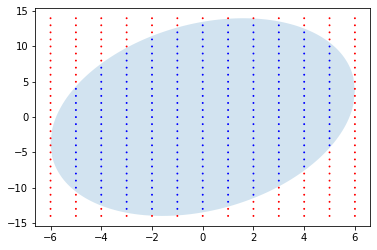

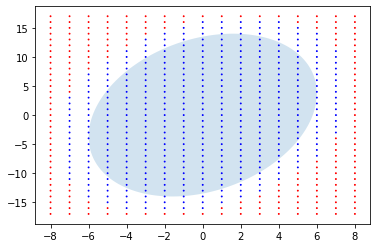

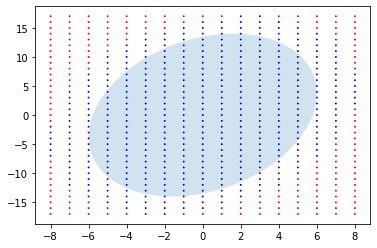

In [13]:
timing_errors = [0, 0.005] # in ms
cond, n2_n3, t2_coinc_window, t3_coinc_window = {}, {}, {}, {}
for i, timing_error in enumerate(timing_errors):
    t2_coinc_window[i] = int(ceil((time_diff_12 + timing_error) * sample_rate))
    t3_coinc_window[i] = int(ceil((time_diff_13 + timing_error) * sample_rate))
    print(t2_coinc_window, t3_coinc_window)
    n2 = np.arange(-t2_coinc_window[i], t2_coinc_window[i]+1).repeat(2*t3_coinc_window[i]+1)
    n3 = np.tile(np.arange(-t3_coinc_window[i], t3_coinc_window[i]+1), 2*t2_coinc_window[i]+1)
    cond[i] = check_time_delay_is_physical(
        n2, n3, t2_coinc_window[i], t3_coinc_window[i], alpha_23, rounding=False)
    print(sum(cond[i]) / len(cond[i]))
    n2_n3[i] = (n2,n3)

dt = linspace(-t2_coinc_window[0], t2_coinc_window[0], 200)
b3 = array([delay_bounds(i, t2_coinc_window[0], t3_coinc_window[0], alpha_23) for i in dt]).T

fill_between(dt, b3[0], b3[1], alpha=0.2)
colors = where(cond[0], "b", "r")
scatter(*n2_n3[0], marker="o", c=colors, s=0.8)
show()
fill_between(dt, b3[0], b3[1], alpha=0.2)
colors = where(cond[1], "b", "r")
scatter(*n2_n3[1], marker="o", c=colors, s=0.8)
show()
cond[2] = check_time_delay_is_physical(
    n2, n3, t2_coinc_window[1], t3_coinc_window[1], alpha_23, rounding=True)
fill_between(dt, b3[0], b3[1], alpha=0.2)
colors = where(cond[2], "b", "r")
scatter(*n2_n3[1], marker="o", c=colors, s=0.8)
show()

In [6]:
len(cond[0]), sum(cond[1])

(377, 399)

including an extra 62.9% combinations due to inclusion of timing errors


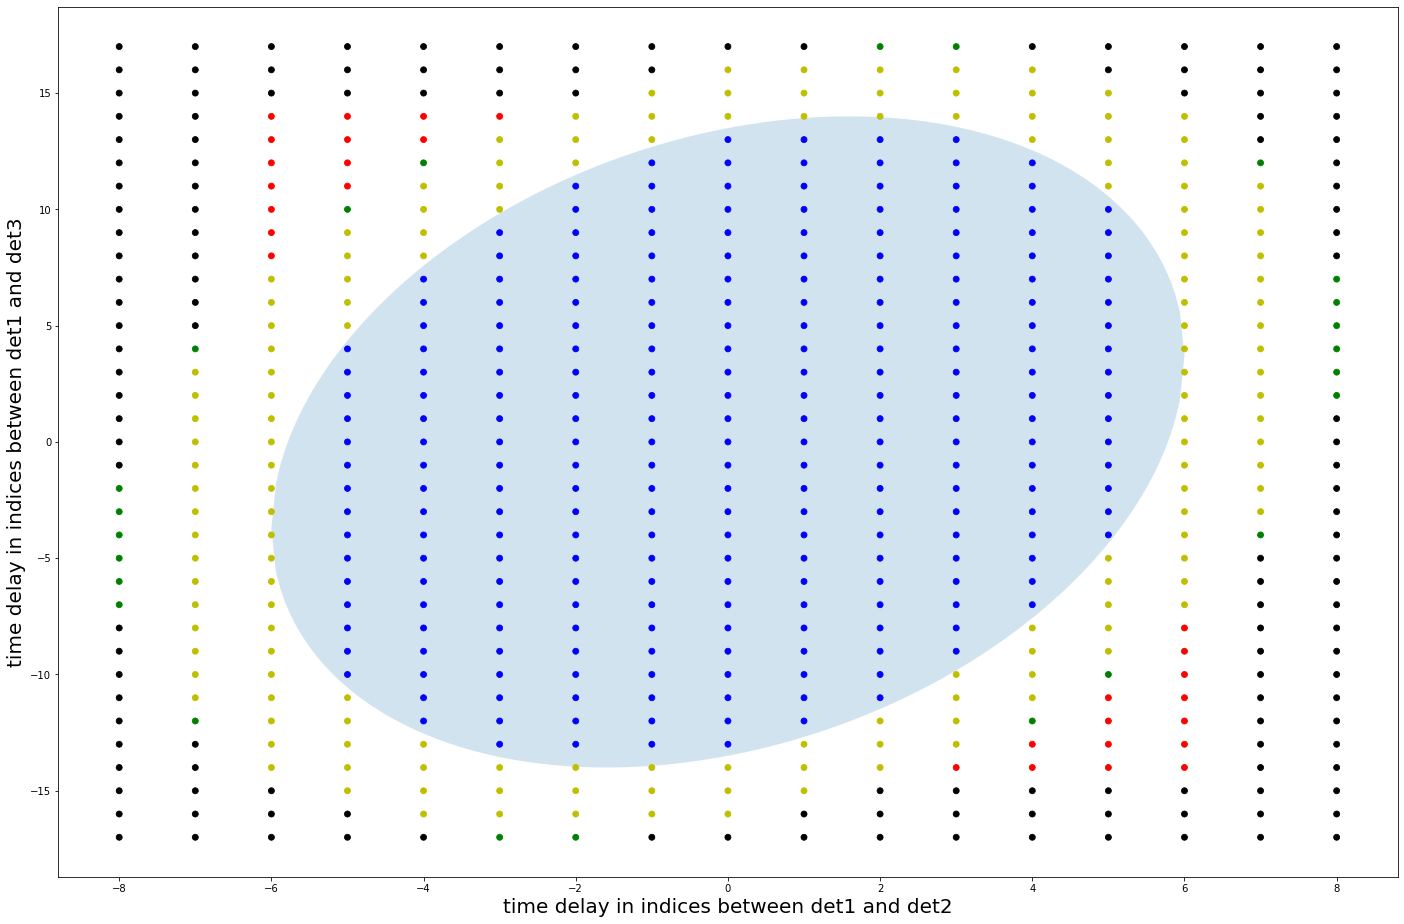

In [14]:
figure(figsize=(24,16))
mask = (abs(n2_n3[1][0])<=t2_coinc_window[0]) & (abs(n2_n3[1][1])<=t3_coinc_window[0])
if sum(~cond[1][mask] & cond[0]): 
    print("Warning: some point accepted only smaller array, this shouldn't happen.")

in_smaller = cond[0]
only_in_larger = cond[1][mask] & ~cond[0]
in_neither = ~(cond[1][mask] | cond[0])
only_from_rounding = ~cond[1] & cond[2]
fill_between(dt, b3[0], b3[1], alpha=0.2)
colors_larger = array(["w"]*len(cond[1]))
colors_larger[mask] = where(in_smaller, "b", colors_larger[mask])
colors_larger[mask] = where(only_in_larger, "y", colors_larger[mask])
colors_larger[cond[1]&~mask] = "y"
colors_larger[mask] = where(in_neither, "r", colors_larger[mask])
colors_larger[~cond[1]&~mask] = "k"
colors_larger[only_from_rounding] = "g"

print("including an extra {:.1f}% combinations due to inclusion of timing errors".format(
    100*sum(colors_larger == "y") / sum(in_smaller)))

scatter(*n2_n3[1], marker="o", c=colors_larger, linewidth=0.8)
xlabel("time delay in indices between det1 and det2", fontsize=20)
ylabel("time delay in indices between det1 and det3", fontsize=20);

## Description of above:

Blue region is the true region that is physical (not including errors).

Blue dots are those within this region. 

Yellow dots show the points that are only counted as physical when including timing errors.

Green show the extra points counted as physical if you attempt to round to the nearest pixel.

black and red dots are non-physical regions. 
